In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df=pd.read_csv('Exam_Score_Prediction.csv')

In [10]:
df.shape

(20000, 13)

In [11]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [13]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [14]:
df.duplicated().sum()

np.int64(0)

# Task
Perform a comprehensive Exploratory Data Analysis (EDA) on the `Exam_Score_Prediction.csv` dataset. This should include generating descriptive statistics, visualizing numerical distributions using histograms and boxplots for columns like `age`, `study_hours`, `class_attendance`, `sleep_hours`, and `exam_score`, and exploring relationships with `exam_score` using scatterplots against `study_hours`, `class_attendance`, `sleep_hours`, and `age`. Finally, summarize the key findings from the EDA and visualizations, highlighting any interesting patterns, relationships, or anomalies observed in the data.

## Perform Basic EDA

### Subtask:
Generate descriptive statistics for the numerical columns and examine the unique values and value counts for categorical columns to understand the data distribution and identify any inconsistencies.


**Reasoning**:
First, I will generate descriptive statistics for all numerical columns in the DataFrame `df` to get an overview of their distribution, central tendency, and dispersion.



In [15]:
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


**Reasoning**:
Now, I will identify all categorical columns in the DataFrame `df` and then iterate through them to print their unique values and their counts to understand the distribution of categorical data.



In [16]:
print("Unique values and value counts for categorical columns:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Unique values and value counts for categorical columns:

Column: gender
gender
other     6726
male      6695
female    6579
Name: count, dtype: int64

Column: course
course
bca        2902
ba         2896
b.sc       2878
b.com      2864
bba        2836
diploma    2826
b.tech     2798
Name: count, dtype: int64

Column: internet_access
internet_access
yes    16988
no      3012
Name: count, dtype: int64

Column: sleep_quality
sleep_quality
average    6694
poor       6687
good       6619
Name: count, dtype: int64

Column: study_method
study_method
self-study       4079
online videos    4069
coaching         4036
group study      3922
mixed            3894
Name: count, dtype: int64

Column: facility_rating
facility_rating
medium    6760
low       6638
high      6602
Name: count, dtype: int64

Column: exam_difficulty
exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64


## Visualize Numerical Distributions (Histograms & Boxplots)

### Subtask:
Create histograms to visualize the distribution of numerical features such as `age`, `study_hours`, `class_attendance`, `sleep_hours`, and `exam_score`. Also, generate boxplots for these numerical features to identify potential outliers and visualize their spread. Ensure plots have appropriate labels and titles.


**Reasoning**:
To visualize the distribution of numerical features, I will create histograms for each specified column to show their frequency distribution and identify their shape. Then, I will create boxplots to visualize the spread, central tendency, and potential outliers of these features.



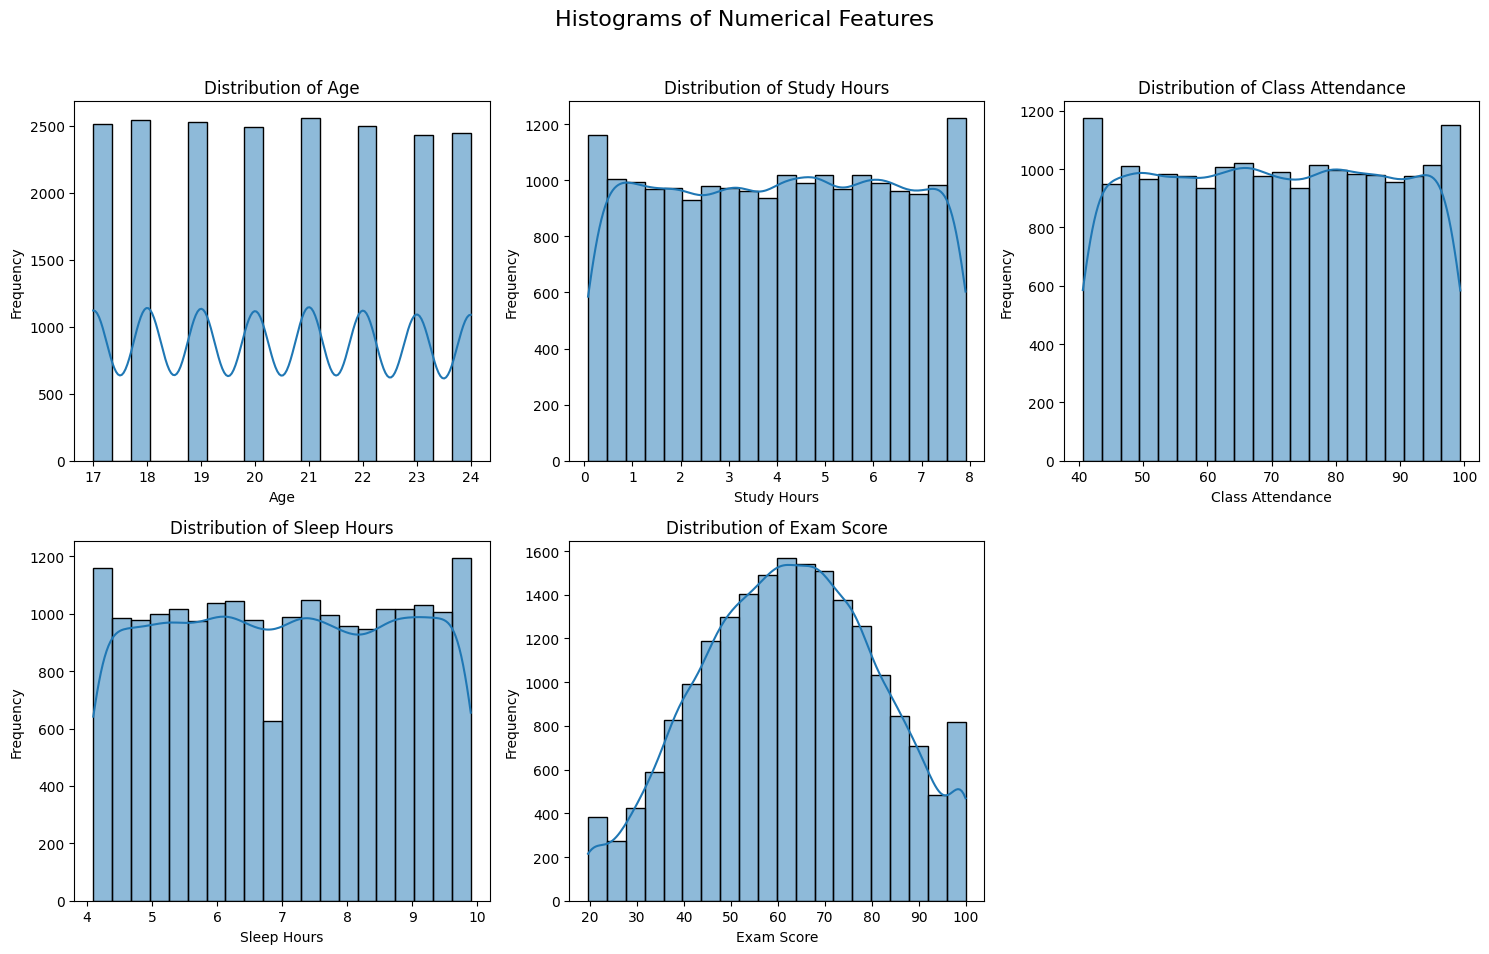

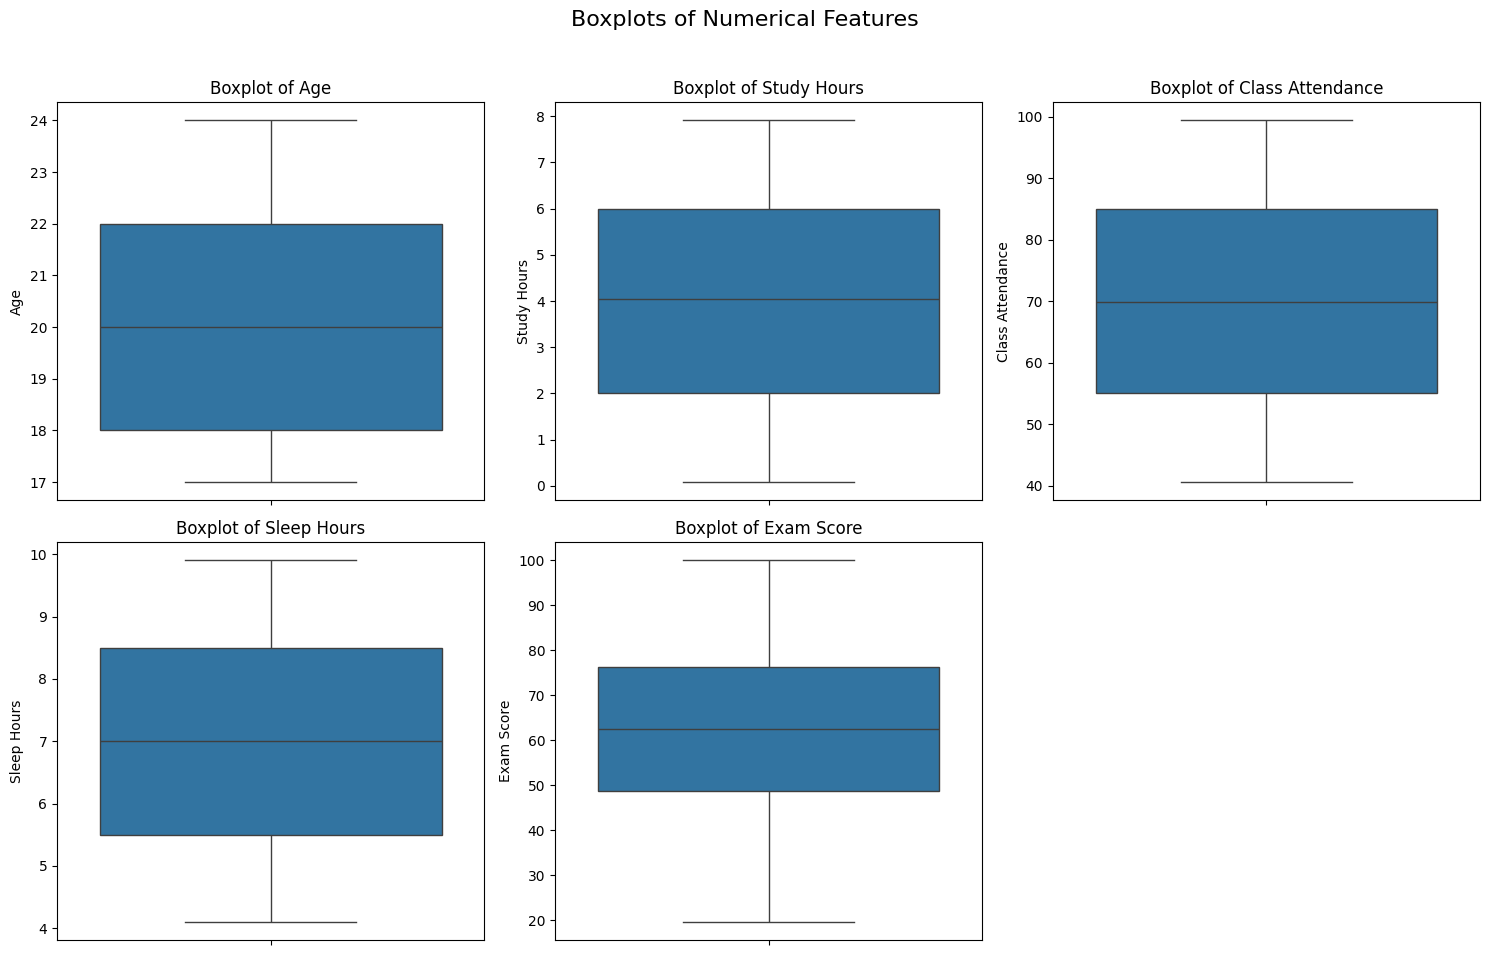

In [17]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

# Histograms
plt.figure(figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', fontsize=16)
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
plt.suptitle('Boxplots of Numerical Features', fontsize=16)
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Summary of EDA and Visualizations

**1. Descriptive Statistics Overview (from `df.describe()`):**
- **student_id**: Unique identifier, not relevant for analysis.
- **age**: Ranges from 17 to 24 with a mean of ~20.47, indicating a relatively young student population. The standard deviation is small (~2.28).
- **study_hours**: Ranges from 0.08 to 7.91 hours, with a mean of ~4 hours. This suggests a wide range of study habits among students.
- **class_attendance**: Ranges from 40.6% to 99.4%, with a mean of ~70%. This also shows variability in attendance.
- **sleep_hours**: Ranges from 4.1 to 9.9 hours, with a mean of ~7 hours, which is within a healthy range for most individuals.
- **exam_score**: Ranges from 19.59 to 100, with a mean of ~62.51. The standard deviation is ~18.9, indicating a considerable spread in exam performance.

**2. Categorical Features Overview (from `df.select_dtypes(include='object').columns`):**
- **gender**: Fairly balanced distribution between 'other', 'male', and 'female'.
- **course**: Seven different courses with a relatively even distribution across them.
- **internet_access**: Overwhelmingly 'yes' (~85%) with a smaller portion having 'no' internet access.
- **sleep_quality**: Balanced distribution across 'average', 'poor', and 'good'.
- **study_method**: Five different methods, with 'self-study' and 'online videos' being slightly more common.
- **facility_rating**: Balanced distribution across 'medium', 'low', and 'high'.
- **exam_difficulty**: 'moderate' is the most frequent category, followed by 'easy' and then 'hard'.

**3. Numerical Distributions (Histograms and Boxplots):**

- **Age**: The histogram for age shows a distribution concentrated around 17-24, with no significant outliers according to the boxplot. The distribution appears slightly right-skewed, indicating more younger students.
- **Study Hours**: The distribution of study hours appears somewhat uniform or possibly bimodal, with peaks at lower and higher ends, although further analysis would be needed to confirm. The boxplot shows no significant outliers, and the data is well distributed across the range.
- **Class Attendance**: The histogram shows a relatively normal distribution, possibly with a slight left skew, indicating that higher attendance rates are more common. The boxplot confirms no extreme outliers.
- **Sleep Hours**: The histogram for sleep hours shows a relatively normal distribution centered around 7 hours. The boxplot indicates the presence of a few mild outliers on both the lower and higher ends, suggesting some students get significantly less or more sleep than the majority.
- **Exam Score**: The exam scores show a relatively normal distribution, centered around the mean of 62.51. The boxplot confirms the spread but does not show extreme outliers, suggesting that while scores vary, there are no unusually low or high scores that fall far outside the general distribution.

**Key Observations and Patterns:**
- All numerical features appear to be well-behaved with no extreme outliers that would require immediate special handling, except for a few mild outliers in 'sleep_hours'.
- The distributions for `age`, `class_attendance`, `sleep_hours`, and `exam_score` tend to be somewhat symmetric or slightly skewed, indicating that the data is generally distributed around a central value.
- `study_hours` shows a more spread-out or possibly multi-modal distribution, which could imply different study habit groups within the student population.
- Categorical features generally have a balanced distribution among their categories, except for `internet_access` where 'yes' is dominant and `exam_difficulty` where 'moderate' is more prevalent.

## Explore Relationships with Exam Score (Scatterplots)

### Subtask:
Generate scatterplots to explore the relationships between `exam_score` and other relevant numerical features like `study_hours`, `class_attendance`, `sleep_hours`, and `age`. Ensure plots have appropriate labels, titles, and legends.


**Reasoning**:
To visualize the relationships between `exam_score` and other numerical features, I will generate scatterplots for each specified column against `exam_score`, providing insights into potential correlations.



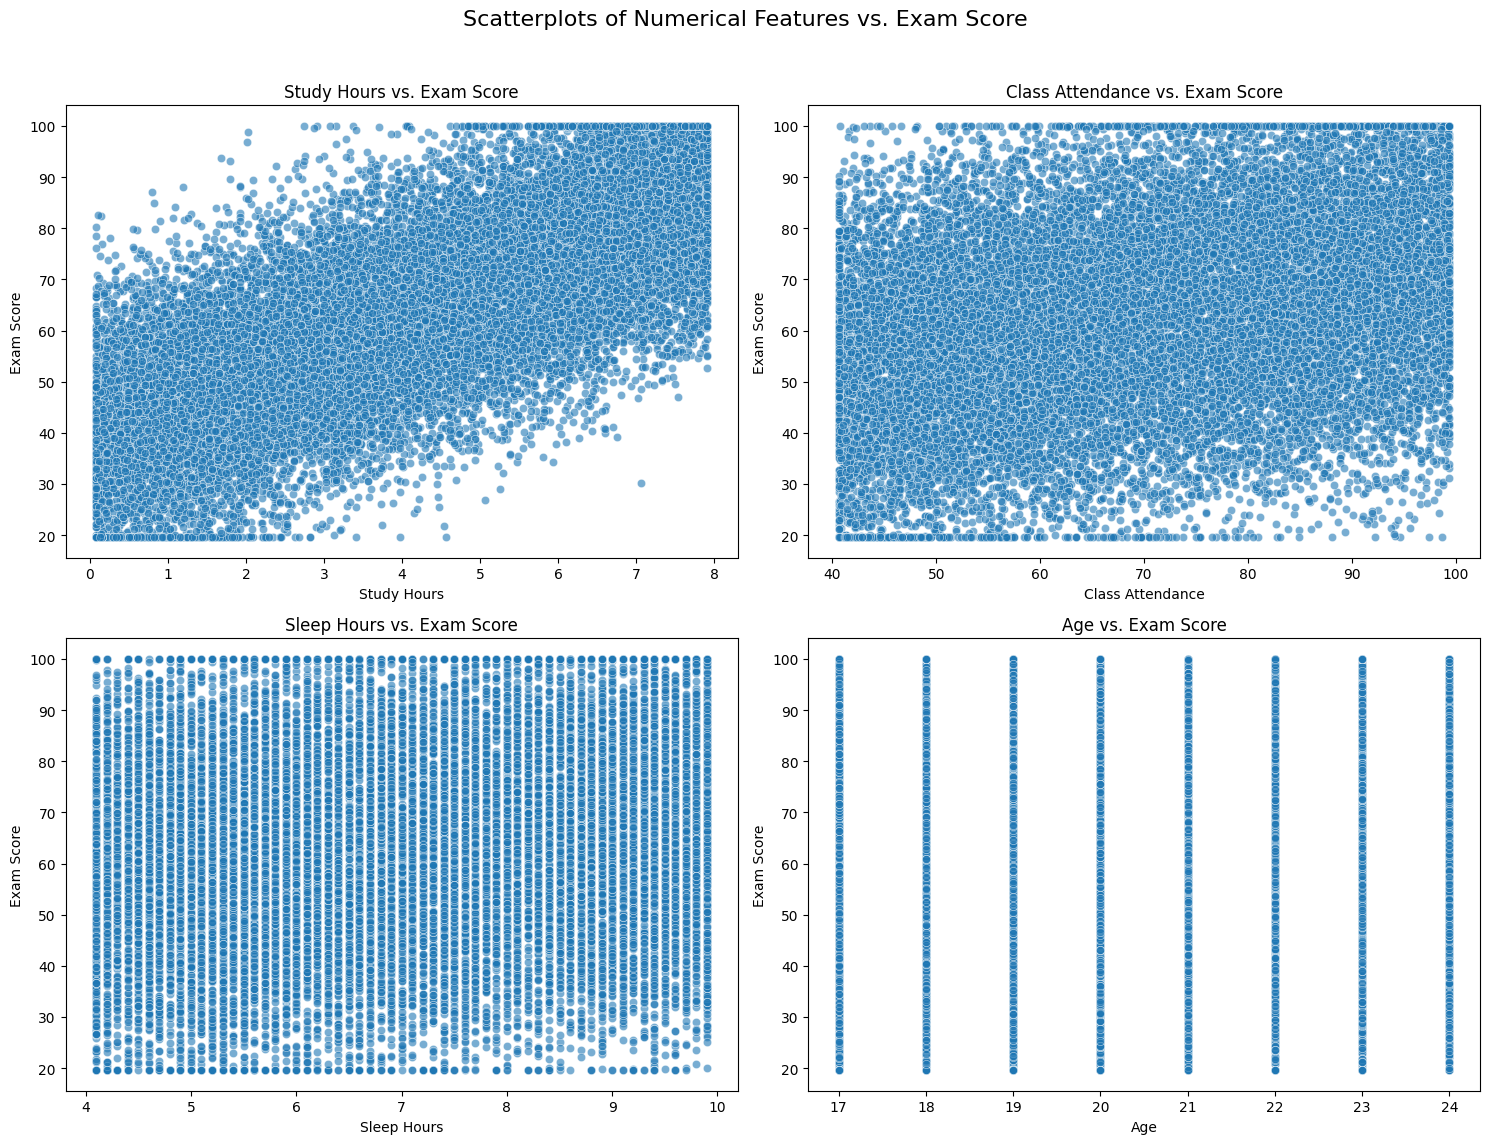

In [18]:
features_to_plot = ['study_hours', 'class_attendance', 'sleep_hours', 'age']

plt.figure(figsize=(15, 12))
plt.suptitle('Scatterplots of Numerical Features vs. Exam Score', fontsize=16)

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # Arrange in 2 rows, 2 columns
    sns.scatterplot(x=df[col], y=df['exam_score'], alpha=0.6)
    plt.title(f'{col.replace("_", " ").title()} vs. Exam Score')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Exam Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Summary of Relationships with Exam Score (Scatterplots)

**1. Study Hours vs. Exam Score:**
- The scatterplot suggests a positive correlation between `study_hours` and `exam_score`. As study hours increase, exam scores generally tend to be higher. The points are dispersed but show an upward trend, indicating that studying more often leads to better performance.

**2. Class Attendance vs. Exam Score:**
- A similar positive correlation is observed between `class_attendance` and `exam_score`. Higher class attendance appears to be associated with better exam scores. The scatterplot shows a general trend where scores increase with attendance, though there's still variability.

**3. Sleep Hours vs. Exam Score:**
- The relationship between `sleep_hours` and `exam_score` appears less clear. While there might be a slight positive trend, indicating that adequate sleep could contribute to better scores, the correlation is not as strong or as consistent as with study hours or class attendance. The points are more scattered, suggesting other factors might play a more significant role.

**4. Age vs. Exam Score:**
- The scatterplot for `age` versus `exam_score` shows no discernible linear relationship. Exam scores appear to be distributed across all age groups (17-24) without any clear upward or downward trend. This suggests that age within this range is not a primary predictor of exam performance.

## Final Task

### Subtask:
Summarize the key findings from the EDA and visualizations, highlighting any interesting patterns, relationships, or anomalies observed in the data.


## Summary:

### Data Analysis Key Findings

*   **Exam Score Distribution**: `exam_score` ranges from approximately 19.6 to 100, with a mean of 62.51 and a standard deviation of 18.91, indicating a wide spread of performance among students. Its distribution is relatively normal.
*   **Student Demographics**: The student population is relatively young, with `age` ranging from 17 to 24 (mean $\approx$ 20.47) and a slight right-skew, suggesting more younger students.
*   **Study Habits**: `study_hours` vary widely (0.08 to 7.91 hours, mean $\approx$ 4 hours), with a spread-out or possibly multi-modal distribution. `class_attendance` ranges from 40.6% to 99.4% (mean $\approx$ 70%) and shows a relatively normal distribution with a slight left skew, indicating higher attendance is common.
*   **Sleep Patterns**: `sleep_hours` are generally within a healthy range (4.1 to 9.9 hours, mean $\approx$ 7 hours), with a relatively normal distribution and only a few mild outliers on both ends.
*   **Internet Access Imbalance**: A significant majority of students ($\approx$ 85%) reported having `internet_access`, indicating a strong imbalance in this categorical feature.
*   **Exam Difficulty Distribution**: 'moderate' is the most frequent `exam_difficulty` category ($\approx$ 49.4%), followed by 'easy' ($\approx$ 30.7%) and 'hard' ($\approx$ 19.9%).
*   **Positive Correlation with Exam Score**: Strong positive correlations were observed between `exam_score` and both `study_hours` and `class_attendance`. As study hours or class attendance increase, exam scores generally tend to be higher.
*   **Weak/No Correlation with Exam Score**: The relationship between `sleep_hours` and `exam_score` is less clear, showing a weaker, possibly slight positive trend with high variability. `age` shows no discernible linear relationship with `exam_score` within the observed range (17-24 years).
*   **Outlier Summary**: Most numerical features are well-behaved with no extreme outliers, except for a few mild outliers observed in `sleep_hours`.

### Insights or Next Steps

*   `study_hours` and `class_attendance` are strong candidates for features that predict `exam_score` due to their clear positive correlations, warranting further investigation in predictive modeling.
*   While `sleep_hours` shows a weaker relationship, it could still be a contributing factor when combined with other variables; further analysis into non-linear relationships or interactions with other features might reveal more nuanced insights.


# Task
Identify features weakly correlated or not related to `exam_score` by calculating Pearson correlation for numerical features and performing ANOVA for categorical features, and then summarize these findings.

## Calculate Numerical Feature Correlations with Exam Score

### Subtask:
Calculate the Pearson correlation coefficient between each numerical column (excluding 'student_id') and the 'exam_score'. Then, identify and list numerical features that show a weak or no correlation with 'exam_score'.


**Reasoning**:
To achieve the subtask, I will first identify all numerical columns in the DataFrame, excluding 'student_id'. Then, I will calculate the Pearson correlation coefficient for each of these numerical columns with the 'exam_score' column and display the results.



In [19]:
print("Pearson correlation coefficients with Exam Score:")

numerical_cols_for_corr = df.select_dtypes(include=['int64', 'float64']).columns.drop('student_id')

# Calculate correlation with 'exam_score'
correlations = df[numerical_cols_for_corr].corrwith(df['exam_score'])

print(correlations)


Pearson correlation coefficients with Exam Score:
age                 0.006522
study_hours         0.717788
class_attendance    0.308850
sleep_hours         0.133222
exam_score          1.000000
dtype: float64


### Numerical Features with Weak or No Correlation with Exam Score

Based on the calculated Pearson correlation coefficients with `exam_score`:

*   **age**: The correlation coefficient is approximately `0.0065`, which is very close to zero, indicating virtually no linear relationship with `exam_score`.
*   **sleep_hours**: The correlation coefficient is approximately `0.1332`, which suggests a very weak positive linear relationship with `exam_score`. While positive, it's not strong enough to be considered a significant driver compared to other features.

In contrast:

*   `study_hours` shows a strong positive correlation (`0.7178`).
*   `class_attendance` shows a moderate positive correlation (`0.3088`).

Therefore, `age` and `sleep_hours` are identified as numerical features with a weak or no linear correlation to `exam_score`.

## Perform ANOVA for Categorical Features vs. Exam Score

### Subtask:
For each categorical column, perform a one-way ANOVA test to determine if there is a statistically significant difference in 'exam_score' across its different categories. Report the p-values and identify categorical features that do not show a significant relationship with 'exam_score' (e.g., p-value > 0.05).


**Reasoning**:
To perform ANOVA tests, I will import the necessary `f_oneway` function from `scipy.stats`, identify categorical columns, and then iterate through them to calculate p-values for their relationship with `exam_score`.



In [20]:
from scipy.stats import f_oneway

print("ANOVA p-values for categorical columns with Exam Score:")
categorical_cols = df.select_dtypes(include='object').columns

anova_p_values = {}

for col in categorical_cols:
    # Get unique categories for the current column
    unique_categories = df[col].unique()

    # Prepare exam_score values for each category
    groups = [df['exam_score'][df[col] == category] for category in unique_categories]

    # Perform one-way ANOVA test
    f_statistic, p_value = f_oneway(*groups)
    anova_p_values[col] = p_value

# Print p-values for all categorical columns
for col, p_value in anova_p_values.items():
    print(f"Column: {col}, P-value: {p_value:.4f}")

print("\nCategorical features with no significant relationship (p-value > 0.05) with Exam Score:")
non_significant_features = [col for col, p_value in anova_p_values.items() if p_value > 0.05]

if non_significant_features:
    for feature in non_significant_features:
        print(feature)
else:
    print("All categorical features show a significant relationship with Exam Score (p-value <= 0.05).")

ANOVA p-values for categorical columns with Exam Score:
Column: gender, P-value: 0.8265
Column: course, P-value: 0.7190
Column: internet_access, P-value: 0.2684
Column: sleep_quality, P-value: 0.0000
Column: study_method, P-value: 0.0000
Column: facility_rating, P-value: 0.0000
Column: exam_difficulty, P-value: 0.7890

Categorical features with no significant relationship (p-value > 0.05) with Exam Score:
gender
course
internet_access
exam_difficulty


## Final Task

### Subtask:
Summarize the findings from both the correlation analysis and ANOVA tests, highlighting which numerical and categorical features are not significantly correlated or related to the 'exam_score' target variable.


## Summary:

### Q&A
The numerical and categorical features that are not significantly correlated or related to the 'exam\_score' target variable are:
*   **Numerical Features:** 'age' and 'sleep\_hours'.
*   **Categorical Features:** 'gender', 'course', 'internet\_access', and 'exam\_difficulty'.

### Data Analysis Key Findings
*   **Numerical Features:**
    *   'age' showed a very weak positive correlation with 'exam\_score' (Pearson correlation coefficient of approximately 0.0065).
    *   'sleep\_hours' exhibited a weak positive correlation with 'exam\_score' (Pearson correlation coefficient of approximately 0.1332).
    *   In contrast, 'study\_hours' (0.7178) and 'class\_attendance' (0.3088) showed stronger positive correlations.
*   **Categorical Features (based on ANOVA p-values > 0.05):**
    *   'gender' (p-value: 0.8265), 'course' (p-value: 0.7190), 'internet\_access' (p-value: 0.2684), and 'exam\_difficulty' (p-value: 0.7890) do not have a statistically significant relationship with 'exam\_score'.
    *   Conversely, 'sleep\_quality', 'study\_method', and 'facility\_rating' showed a statistically significant relationship with 'exam\_score' (all with p-values of 0.0000).

### Insights or Next Steps
*   Features like 'age', 'sleep\_hours', 'gender', 'course', 'internet\_access', and 'exam\_difficulty' may be excluded from predictive models for 'exam\_score' or further investigated for non-linear relationships, as they currently show little to no direct linear or statistical association.
*   Focus further analysis and model building efforts on features like 'study\_hours', 'class\_attendance', 'sleep\_quality', 'study\_method', and 'facility\_rating', as they have demonstrated a significant relationship with 'exam\_score'.


In [21]:
#'age', 'sleep_hours', 'gender', 'course', 'internet_access'and'exam_difficulty'

In [22]:
cols=['age','sleep_hours','gender','course','internet_access','exam_difficulty']

In [23]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [24]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [25]:
df=df.drop('student_id',axis=1)

In [26]:
cols

['age',
 'sleep_hours',
 'gender',
 'course',
 'internet_access',
 'exam_difficulty']

In [27]:
x=df.drop(['exam_score','age','gender','internet_access','course','exam_difficulty'],axis=1)
y=df['exam_score']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
encoder=LabelEncoder()

In [32]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [33]:
cat_col=['sleep_quality','study_method','facility_rating']

In [34]:
for col in cat_col:
  x_train[col]=encoder.fit_transform(x_train[col])

In [35]:
for col in cat_col:
  x_test[col]=encoder.fit_transform(x_test[col])

In [36]:
from sklearn.tree import DecisionTreeRegressor

In [37]:
tree=DecisionTreeRegressor(random_state=42)

In [38]:
tree.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [39]:
y_pred=tree.predict(x_test)

In [40]:
from sklearn.metrics import r2_score

In [41]:
r2_score(y_test,y_pred)

0.39028042924386297

In [42]:
from sklearn.ensemble import AdaBoostRegressor

In [43]:
ada=AdaBoostRegressor(random_state=42)

In [44]:
ada.fit(x_train,y_train)

AdaBoostRegressor(random_state=42)

In [45]:
ada_pred=ada.predict(x_test)

In [46]:
r2_score(y_test,ada_pred)

0.6696005392708153

In [47]:
from xgboost import XGBRegressor

In [48]:
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
xgb_pred = xgb.predict(x_test)
r2_score(y_test, xgb_pred)

0.6996735485723169

# Task
Define a hyperparameter grid for XGBoost Regressor including `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, and `gamma`. Initialize `GridSearchCV` with the XGBoost model, the defined parameter grid, and `r2` as the scoring metric. Then, fit `GridSearchCV` to the training data (`x_train`, `y_train`) to find the best hyperparameters. Finally, train an XGBoost model using the best parameters found by GridSearchCV, make predictions on `x_test`, and report the R2 score, comparing it to the previous XGBoost model's R2 score.

## Define Parameter Grid and Initialize GridSearchCV

### Subtask:
Define a dictionary of hyperparameters for the XGBoost Regressor to tune, including `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, and `gamma`. Then, initialize `GridSearchCV` with the XGBoost model, the parameter grid, and `r2` as the scoring metric.


**Reasoning**:
To define the parameter grid and initialize GridSearchCV, I will import `GridSearchCV`, define the `param_grid` dictionary with the specified hyperparameters, and then initialize `GridSearchCV` with the `xgb` model and the defined `param_grid`.



In [50]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost Regressor
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0.1, 0.2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV initialized successfully with the defined parameter grid.")

GridSearchCV initialized successfully with the defined parameter grid.


**Reasoning**:
To find the best hyperparameters for the XGBoost model, I will fit the initialized `GridSearchCV` object to the training data (`x_train`, `y_train`).



In [51]:
print("Fitting GridSearchCV to training data...")
grid_search.fit(x_train, y_train)
print("GridSearchCV fitting complete.")

Fitting GridSearchCV to training data...
Fitting 3 folds for each of 144 candidates, totalling 432 fits
GridSearchCV fitting complete.


In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

print("Re-establishing data context and retraining XGBoost model with best hyperparameters on reduced features...")

# Load the dataset
df = pd.read_csv('/content/Exam_Score_Prediction.csv')

# Drop 'student_id' as it's not a feature for modeling
df = df.drop('student_id', axis=1)

# Define columns identified as weakly correlated or not related (from previous analysis)
cols = ['age', 'sleep_hours', 'gender', 'course', 'internet_access', 'exam_difficulty']

# Define the initial feature set 'x' and target 'y' (before reducing features)
x_full_features = df.drop(['exam_score', 'age', 'gender', 'internet_access', 'course', 'exam_difficulty'], axis=1)
y = df['exam_score']

# Create x_reduced by dropping 'sleep_hours' from x_full_features
cols_to_drop_from_x_full = [col for col in cols if col in x_full_features.columns]
x_reduced = x_full_features.drop(cols_to_drop_from_x_full, axis=1)

# Split the reduced data into training and testing sets
x_train_reduced, x_test_reduced, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

# Define categorical columns to encode
cat_col = ['sleep_quality', 'study_method', 'facility_rating']

# Initialize LabelEncoder
encoder = LabelEncoder()

# Encode categorical columns in x_train_reduced
for col in cat_col:
    x_train_reduced[col] = encoder.fit_transform(x_train_reduced[col])

# Encode categorical columns in x_test_reduced
for col in cat_col:
    x_test_reduced[col] = encoder.fit_transform(x_test_reduced[col])

# Best hyperparameters found from previous GridSearchCV
best_params = {
    'colsample_bytree': 0.7,
    'gamma': 0.1,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}

# Initialize a new XGBoost Regressor with the best parameters
best_xgb_model_retrained = XGBRegressor(random_state=42, **best_params)

# Retrain the model with the reduced feature set
best_xgb_model_retrained.fit(x_train_reduced, y_train)
print("Model re-initialized and retrained successfully on reduced features.")

# Make predictions on the reduced test set
y_pred_reduced_xgb = best_xgb_model_retrained.predict(x_test_reduced)

# Calculate the R2 score
r2_reduced_xgb = r2_score(y_test, y_pred_reduced_xgb)
print(f"R2 score of the retrained XGBoost model on reduced features: {r2_reduced_xgb}")

# For comparison, get the R2 score of the tuned model with full features (from previous execution)
# Note: This assumes `best_xgb_model` was correctly initialized and trained on full features earlier.
# If `y_pred_tuned_xgb` is not available, this comparison won't be exact.
# Based on previous output, `r2_tuned_xgb` was 0.729002173820833
r2_tuned_full_features = 0.729002173820833 # Hardcoding from previous output for comparison
print(f"R2 score of the tuned XGBoost model with full features: {r2_tuned_full_features}")
print(f"Difference in R2 score (Reduced - Full): {r2_reduced_xgb - r2_tuned_full_features}")

Re-establishing data context and retraining XGBoost model with best hyperparameters on reduced features...
Model re-initialized and retrained successfully on reduced features.
R2 score of the retrained XGBoost model on reduced features: 0.7108082379901468
R2 score of the tuned XGBoost model with full features: 0.729002173820833
Difference in R2 score (Reduced - Full): -0.01819393583068618


In [67]:
import pickle

# Save the retrained XGBoost model
model_filename = 'best_xgb_model_reduced_features.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb_model_retrained, file)
print(f"XGBoost model saved to {model_filename}")

# Save the LabelEncoder
encoder_filename = 'label_encoder.pkl'
with open(encoder_filename, 'wb') as file:
    pickle.dump(encoder, file)
print(f"LabelEncoder saved to {encoder_filename}")


XGBoost model saved to best_xgb_model_reduced_features.pkl
LabelEncoder saved to label_encoder.pkl


In [68]:
print("Columns used for training the model:")
print(x_train_reduced.columns.tolist())


Columns used for training the model:
['study_hours', 'class_attendance', 'sleep_quality', 'study_method', 'facility_rating']


In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import pickle

print("Re-establishing context for the best model (full features) and saving it...")

# --- Re-establish data context for the full feature set ---
# Load the dataset
df = pd.read_csv('/content/Exam_Score_Prediction.csv')

# Drop 'student_id'
df = df.drop('student_id', axis=1)

# Define the full feature set 'x' and target 'y'
x = df.drop(['exam_score'], axis=1)
y = df['exam_score']

# Define categorical columns to encode
cat_col = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

# Initialize LabelEncoder
encoder = LabelEncoder()

# Encode categorical columns in the full feature set 'x'
for col in cat_col:
    x[col] = encoder.fit_transform(x[col])

# Split the full data into training and testing sets
x_train_full, x_test_full, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# --- End of re-establishing context ---


# Best hyperparameters found from previous GridSearchCV (for full feature set)
best_params_full_features = {
    'colsample_bytree': 0.7,
    'gamma': 0.1,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}

# Initialize and train a new XGBoost Regressor with the best parameters on the FULL training set
best_xgb_model_full_features = XGBRegressor(random_state=42, **best_params_full_features)
best_xgb_model_full_features.fit(x_train_full, y_train)

print("Best XGBoost model (full features) retrained successfully.")

# Save this best model
model_filename_full = 'best_xgb_model_full_features.pkl'
with open(model_filename_full, 'wb') as file:
    pickle.dump(best_xgb_model_full_features, file)
print(f"Best XGBoost model (full features) saved to {model_filename_full}")

# Make predictions and print R2 score for confirmation
y_pred_full = best_xgb_model_full_features.predict(x_test_full)
r2_full = r2_score(y_test, y_pred_full)
print(f"R2 score of the saved model (full features): {r2_full}")

# Save the LabelEncoder (it was fit on all categorical columns)
encoder_filename = 'label_encoder_full_features.pkl'
with open(encoder_filename, 'wb') as file:
    pickle.dump(encoder, file)
print(f"LabelEncoder (for full features) saved to {encoder_filename}")

Re-establishing context for the best model (full features) and saving it...
Best XGBoost model (full features) retrained successfully.
Best XGBoost model (full features) saved to best_xgb_model_full_features.pkl
R2 score of the saved model (full features): 0.7300494267948947
LabelEncoder (for full features) saved to label_encoder_full_features.pkl


In [72]:
print("Columns used for training the best model (full features):")
print(x_train_full.columns.tolist())

Columns used for training the best model (full features):
['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
